In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import ArtistAnimation
from IPython.display import HTML

Initial Condition

Left State:

    rhoL = 1.0 

    velL = 0.0

    preL = 1.0

Right State:

    rhoR = 0.125

    velR = 0.0

    preR = 0.1


In [39]:
def prepareanimation():
    global figA, artistA
    #set up for animation
    figA = plt.figure(figsize=(8,6))
    artistA = []

    #plt.xlim(-0.5*Lx,0.5*Lx)
    plt.xlabel(r'$x$')


In [40]:
def addanimation(cel_center, rho, u, p):

    global artistA

    plt.xlabel(r'$x$')
    im1 = plt.plot(cel_center, rho, color='blue',label=r"$\rho$",)
    im2 = plt.plot(cel_center, u, color='red',label=r"$v$",)
    im3 = plt.plot(cel_center, p, color='green',label=r"$P$")
    
    figA.tight_layout()
    plt.legend()
    
    artistA.append(im1 + im2 + im3)

In [2]:
def godunov(ist, ien, dt, dx, rho, mom,  ene, frho, fmom, fe):
    
    for i in range(ist, ien-1):
        rho[i] = rho[i] - dt/dx*( frho[i] - frho[i-1] )
        mom[i] = mom[i] - dt/dx*( fmom[i] - fmom[i-1] )
        ene[i] = ene[i] - dt/dx*( fe[i] - fe[i-1] )

In [45]:
def hllc(rhoL, uL, pL, rhoR, uR, pR):
    global gamma

    rhoL = rhoL
    uL = uL
    pL = pL 

    rhoR = rhoR
    uR = uR
    pR = pR

    gamma = 1.4
   
    aL = np.sqrt(gamma * pL / rhoL)
    aR = np.sqrt(gamma * pR / rhoR)


    c_l = np.sqrt(gamma*pL*rhoL)

    c_r = np.sqrt(gamma*pR*rhoR)
    
    print(pL)    
    v_star = (c_l * uL - c_r * uR + pR - pL) / (c_l - c_r)

    p_star = pL + c_l * (v_star - uL)


    s = np.zeros(3)


    if p_star >= pL: #shock
        s[0] = rhoL*(p_star/pL + gamma-1/gamma+1)/( gamma-1/gamma+1*p_star/pL + 1.0)
        rho_star = rhoL*(p_star/pL + gamma-1/gamma+1)/( gamma-1/gamma+1*p_star/pL + 1.0)
    else: #rarefaction
        s[0] = 0.5*( uL - aL + v_star - np.sqrt(gamma*p_star/rhoL) )
        rho_star = rhoL * (p_star/pL)**(1/gamma)

    if p_star >= pR: #shock
        s[2] = rhoR*(p_star/pR + gamma-1/gamma+1)/( gamma-1/gamma+1*p_star/pR + 1.0)
        rho_star = rhoR*(p_star/pR + gamma-1/gamma+1)/( gamma-1/gamma+1*p_star/pR + 1.0)
    else: #rarefaction
        s[2] = 0.5*( uR + aR + v_star + np.sqrt(gamma*p_star/rhoR) )
        rho_star = rhoR * (p_star/pR)**(1/gamma)

    
    #s[0] = min(uL - np.sqrt(gamma*pL/rhoL), uR - np.sqrt(gamma*pR/rhoR))
    #s[2] = max(uL + np.sqrt(gamma*pL/rhoL), uR + np.sqrt(gamma*pR/rhoR))
    s[1] = v_star


    if s[0] >= 0: #wL
        frho =  rhoL * uL
        fmom= rhoL * uL**2 + pL
        fe = (gamma*pL/(gamma-1) + 0.5*rhoL*uL**2 + pL) * uL
    elif s[1] >= 0: #wL*
        frho =  rhoL * uL
        fmom= rhoL * uL**2 + pL
        fe = (gamma*pL/(gamma-1) + 0.5*rhoL*uL**2 + pL) * uL

    elif s[1] <= 0: #wR*
        frho =  rhoR * uR
        fmom= rhoR * uR**2 + pR
        fe = (gamma*pR/(gamma-1) + 0.5*rhoR*uR**2 + pR) * uR

    else:  #wR
        frho =  rhoR * uR
        fmom= rhoR * uR**2 + pR
        fe = (gamma*pR/(gamma-1) + 0.5*rhoR*uR**2 + pR) * uR

    return frho, fmom, fe

1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
1.0
0.1
0.1
0.1
0.1
0.1
0.1
0.1
0.1
0.1
0.1
0.1
0.1
0.1
0.1
0.1
2.2142857142857144
2.5000000000000004
2.5000000000000004
2.5000000000000004
2.5000000000000004
2.5000000000000004
2.5000000000000004
2.5000000000000004
2.5000000000000004
2.5000000000000004
2.5000000000000004
2.5000000000000004
2.5000000000000004
2.268571428571429
2.0000000000000004
2.0000000000000004
2.0000000000000004
2.0000000000000004
2.0000000000000004
2.0000000000000004
2.0000000000000004
2.0000000000000004
2.0000000000000004
2.0000000000000004
2.0000000000000004
2.0000000000000004
2.0000000000000004
2.0000000000000004
2.0000000000000004
3.310557923173071
-1.2180678408148573
2.5000000000000004
2.5000000000000004
2.5000000000000004
2.5000000000000004
2.5000000000000004
2.5000000000000004
2.5000000000000004
2.5000000000000004
2.5000000000000004
2.5000000000000004
-0.7674096306520909
2.268571428571429
7.620731528856527
2.0000000000000004
2.0000000000000004
2.0000000000

/var/folders/xc/ym24bbrn1lb7fnzh8tj6vqhw0000gn/T/ipykernel_5370/3486998972.py:23: RuntimeWarning: invalid value encountered in scalar divide
  v_star = (c_l * uL - c_r * uR + pR - pL) / (c_l - c_r)
/var/folders/xc/ym24bbrn1lb7fnzh8tj6vqhw0000gn/T/ipykernel_5370/3486998972.py:35: RuntimeWarning: invalid value encountered in sqrt
  s[0] = 0.5*( uL - aL + v_star - np.sqrt(gamma*p_star/rhoL) )
/var/folders/xc/ym24bbrn1lb7fnzh8tj6vqhw0000gn/T/ipykernel_5370/3486998972.py:36: RuntimeWarning: invalid value encountered in scalar power
  rho_star = rhoL * (p_star/pL)**(1/gamma)
/var/folders/xc/ym24bbrn1lb7fnzh8tj6vqhw0000gn/T/ipykernel_5370/3486998972.py:42: RuntimeWarning: invalid value encountered in sqrt
  s[2] = 0.5*( uR + aR + v_star + np.sqrt(gamma*p_star/rhoR) )
/var/folders/xc/ym24bbrn1lb7fnzh8tj6vqhw0000gn/T/ipykernel_5370/3486998972.py:43: RuntimeWarning: invalid value encountered in scalar power
  rho_star = rhoR * (p_star/pR)**(1/gamma)
/var/folders/xc/ym24bbrn1lb7fnzh8tj6vqhw0000gn

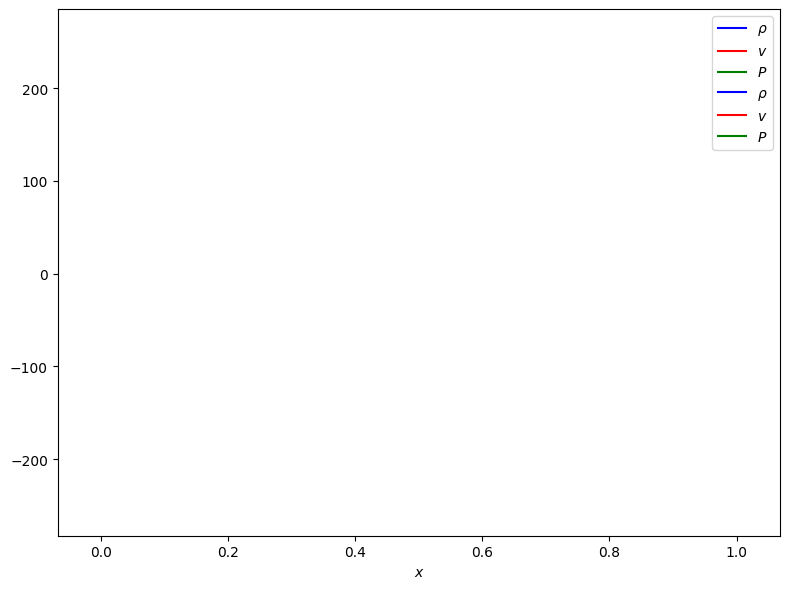

In [46]:
def shocktube1d(rhoL,velL,preL,rhoR,velR,preR):
    
    global ist, ien, dx, ntot, gamma

    #initial conditions
    rhoL = rhoL 
    velL = velL
    preL = preL

    rhoR = rhoR
    velR = velR
    preR = preR

    ngrids = 30
    L = 1.0
    dx = L / ngrids
    cfl = 0.8
    gamma = 1.4
     
    ist = 1
    nghost = ist
    ien = ngrids + nghost
    ntot = ngrids + 2*nghost
    cfl = 0.8

    rho = np.zeros(ntot)
    u = np.zeros(ntot)
    p = np.zeros(ntot)

    #fluxes
    global frho, frhou, fe
    frho = np.zeros(ntot)
    fmom = np.zeros(ntot)
    fe = np.zeros(ntot)

    mom = np.zeros(ntot)
    ene = np.zeros(ntot)

    time = 0
    tout = 0.2

    prepareanimation()


    cel_center = np.zeros(ntot)
    cel_boundary = np.zeros(ntot+1)

    for i in range(ntot +1):
        cel_boundary[i] = (i - ist) * dx

    for i in range(ntot):
        cel_center[i] = 0.5*(cel_boundary[i] + cel_boundary[i+1])

    #profile at t = 0
    x0 = ngrids//2.0 # center of the shock tube

    for i in range(ntot):

        if i < x0:
            rho[i] = rhoL
            u[i] = velL
            p[i] = preL

        else:
            rho[i] = rhoR
            u[i] = velR
            p[i] = preR

        mom[i] = rho[i]*u[i]
        ene[i] = p[i]/(gamma-1) + 0.5*rho[i]*u[i]**2    

    addanimation(cel_center, rho, u, p)

    dt = cfl*dx/min( np.sqrt(gamma*p[ist:ien]/rho[ist:ien ]) + abs(u[ist:ien]))

    while time < tout:
        for i in range(ist, ien-1):
            frho[i], fmom[i], fe[i] = hllc(rho[i], u[i], p[i], rho[i+1], u[i+1], p[i+1])

        godunov(ist, ien, dt, dx, rho, mom,  ene, frho, fmom, fe)

        for i in range(ist, ien):
            
            u[i] = mom[i]/rho[i]
            p[i] = (ene[i] - 0.5*mom[i]*u[i])/rho[i]

        dt = cfl*dx/min( np.sqrt(gamma*p[ist:ien]/rho[ist:ien ]) + abs(u[ist:ien]))
        time = time + dt

    addanimation(cel_center, rho, u, p)


if __name__ == "__main__":
    shocktube1d(rhoL = 1.0 ,velL= 0.0, preL=1.0 ,rhoR=0.125 ,velR=0.0 ,preR=0.1)

anim = ArtistAnimation(figA, artistA, interval=100) 
HTML(anim.to_jshtml())  
